In [7]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import numpy as np

In [8]:
# cria ambiente
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

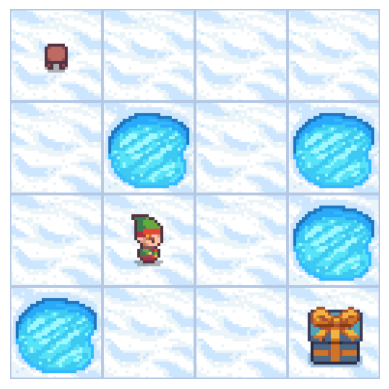

action: UP
reward: 0
new state: 5
info {'prob': 1.0}
*** TERMINATED
Reward final: 0


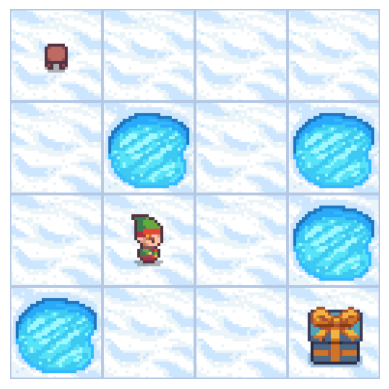

In [4]:
# mapeamento das ações
action_names = {
    0: "LEFT",
    1: "DOWN",
    2: "RIGHT",
    3: "UP"
}


obs, info = env.reset()

done = False

plt.figure()

while not done:

    frame = env.render()

    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis("off")
    display(plt.gcf())

    # política aleatória
    action = env.action_space.sample()
    print("action:", action_names[action])

    new_state, reward, terminated, truncated, info = env.step(action)


    print("reward:", reward)
    print("new state:", new_state)
    print("info", info)

    done = terminated or truncated

    if terminated:
      print("*** TERMINATED")
    if truncated:
      print ("*** TRUNCATED")

    time.sleep(4)

env.close()

print("Reward final:", reward)

In [9]:
import gymnasium as gym
from gymnasium import Wrapper

custom_map = [
    "SHFFF",
    "FHFHF",
    "FFFHF",
    "HHHGF"
]

class HolePenaltyWrapper(Wrapper):
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        # pegar a posição atual
        row = obs // self.env.unwrapped.ncol
        col = obs % self.env.unwrapped.ncol
        
        tile = self.env.unwrapped.desc[row][col].decode("utf-8")
        
        # se caiu em um buraco (H), penaliza
        if tile == "H":
            reward = -1.0
        
        return obs, reward, terminated, truncated, info

env = gym.make(
    "FrozenLake-v1",
    desc=custom_map,
    render_mode="rgb_array",
    is_slippery=False
)

env = HolePenaltyWrapper(env)

In [10]:
alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.999
epsilon_min = 0.05

episodes = 20000

q_table = np.zeros((env.observation_space.n, env.action_space.n))

# lista para guardar rewards por episódio
rewards_per_episode = []

for episode in range(episodes):

    state, info = env.reset()
    done = False

    total_reward = 0  # acumulador do episódio

    while not done:

        # epsilon-greedy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.random.choice(
                np.where(q_table[state] == np.max(q_table[state]))[0]
            )

        new_state, reward, terminated, truncated, info = env.step(action)

        # Q-learning update
        q_table[state, action] += alpha * (
            reward +
            gamma * np.max(q_table[new_state]) -
            q_table[state, action]
        )

        total_reward += reward  # acumula reward

        state = new_state
        done = terminated or truncated

    rewards_per_episode.append(total_reward)  # salva o episódio

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Treinamento finalizado")

Treinamento finalizado


In [11]:
q_table

array([[ 0.88638487,  0.89533825, -1.        ,  0.88638487],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [-1.        ,  0.93206535,  0.95099005,  0.94148015],
       [ 0.94148015, -1.        ,  0.96059601,  0.95099005],
       [ 0.95099005,  0.970299  ,  0.96059601,  0.96059601],
       [ 0.89533825,  0.90438208, -1.        ,  0.88638487],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [-1.        ,  0.92274469, -1.        ,  0.94148015],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [-1.        ,  0.9801    ,  0.970299  ,  0.96059601],
       [ 0.90438208, -1.        ,  0.91351725,  0.89533825],
       [ 0.90438207, -1.        ,  0.92274469, -1.        ],
       [ 0.91351725, -1.        , -1.        ,  0.93206535],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [-1.        ,  0.99      ,  0.9801    ,  0.970299  ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.

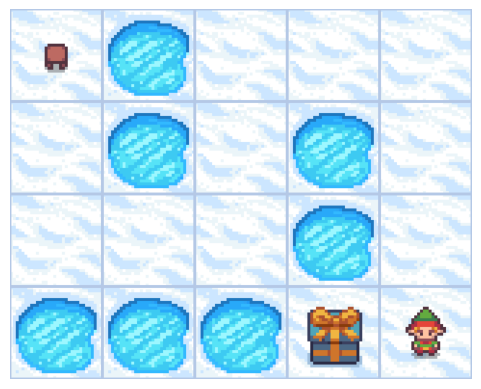

action: LEFT
reward: 1
new state: 18
Reward final: 1


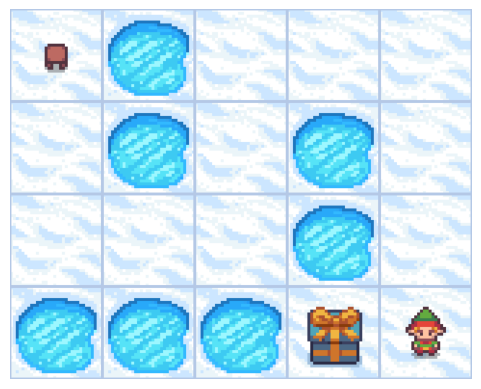

In [12]:
state, info = env.reset()
done = False

plt.figure()

while not done:

    frame = env.render()

    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis("off")
    display(plt.gcf())

    action = np.argmax(q_table[state])

    print("action:", action_names[action])

    new_state, reward, terminated, truncated, info = env.step(action)

    print("reward:", reward)
    print("new state:", new_state)

    state = new_state
    done = terminated or truncated

    time.sleep(1)

env.close()
print("Reward final:", reward)

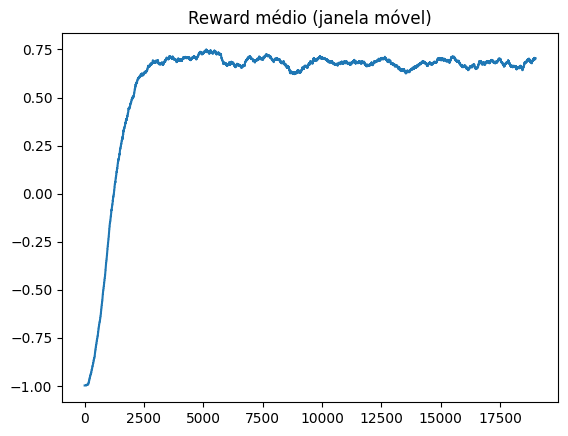

In [13]:
window = 1000
moving_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid')

plt.plot(moving_avg)
plt.title("Reward médio (janela móvel)")
plt.show()